In [1]:
import os 
import joblib
import requests
import datetime
import pandas as pd
import yfinance as yf
import missingno as msno
from fredapi import Fred
from datetime import date 
from dotenv import load_dotenv

In [29]:
load_dotenv(override=True)
EIA_API_KEY = os.environ['EIA_API_KEY']
FRED_API_KEY = os.environ['FRED_API_KEY']
FRED_SERIES = {
    'Inflation': 'CPIAUCSL',       
    'Interest_Rate': 'FEDFUNDS',    
    'USD_EUR': 'DEXUSEU',           
    'USD_JPY': 'DEXJPUS'            
}
FRED_SERIES2 = {            
    'Silver': 'SLV',   
    'SP500': 'SP500'       
}
PATH = r"gold_data.csv"

In [4]:

def read_dataset() -> pd.DataFrame:
    print("="*10 + "MAIN DATASET" + "="*10)
    df = pd.read_csv(PATH)
    df = df.sort_values('Date').reset_index(drop=True)
    print(df.head())
    print("*" *20)

In [5]:
def fetch_oil_prices(start, end):
    url = (
        f'https://api.eia.gov/v2/petroleum/pri/spt/data/'
        f'?api_key={EIA_API_KEY}&frequency=monthly'
        f'&data[0]=value'
        f'&facets[product][]=EPCBRENT'
        f'&start={start}&end={end}'
        f'&sort[0][column]=period&sort[0][direction]=asc'
        f'&length=5000'
    )

    response = requests.get(url)
    response.raise_for_status()
    json_data = response.json()

    data = json_data.get("response", {}).get("data", [])
    if not data:
        raise ValueError("No data found in API response")

    df = pd.DataFrame(data)
    df['Date'] = pd.to_datetime(df['period'])
    df['Value'] = pd.to_numeric(df['value'], errors='coerce')

    return df[['Date', 'Value']]

In [6]:
def preprocess_fred_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.index = pd.to_datetime(df.index)

    for col in ['Inflation', 'Interest_Rate']:
        if col in df.columns:
            df[col] = df[col].ffill()

    for col in ['USD_EUR', 'USD_JPY']:
        if col in df.columns:
            df[col] = df[col].ffill().bfill()

    return df

In [27]:
def fetch_fred_data(start_date, end_date): #--- works okay
    print("fetching fred data")
    start=start_date
    end=end_date
    fred = Fred(api_key=FRED_API_KEY)
    dfs = {
        name: fred.get_series(series_id, observation_start=start, observation_end=end).rename(name)
        for name, series_id in FRED_SERIES2.items()
    }
    combined = pd.concat(dfs.values(), axis=1)
    combined.index = pd.to_datetime(combined.index)
    df = preprocess_fred_data(combined)
    # print(df.head())
    # print(df.tail())
    # print(df.isnull().sum())
    return df

In [8]:
def fetch_gold_prices(start_date, end_date) -> pd.DataFrame:
    print("fetching gold prices")
    gold = yf.download(
        'GLD',
        start=start_date,
        end=end_date,
        auto_adjust=False,     
        group_by='column',   
        progress=False
    )

    if isinstance(gold.columns, pd.MultiIndex):
        gold.columns = [c[0] if isinstance(c, tuple) else c for c in gold.columns]

    gold_prices = gold[['Close']].reset_index()
    gold_prices.rename(columns={'Close': 'Gold_Price'}, inplace=True)
    gold_prices['Date'] = pd.to_datetime(gold_prices['Date'])

    # print(gold_prices.head())
    # print(gold_prices.tail())
    # print(gold_prices.isnull().sum())
    return gold_prices

In [9]:
def merge_datasets(oil_df: pd.DataFrame, fred_df: pd.DataFrame, gold_df: pd.DataFrame) -> pd.DataFrame:
    return gold_df.merge(oil_df, on='Date', how='outer') \
                .merge(fred_df, on='Date', how='outer')

In [10]:
def write_dataset(new_df: pd.DataFrame) -> None:
    # df = read_dataset()
    # print(f"length of main_dataset = {len(df)}")
    # print(f"length of new dataset = {len(new_df)}")

    # combined = pd.concat([df, new_df], axis=0, ignore_index=True)
    # print(f"length of new version of main dataset = {len(combined)}")
    new_df.to_csv(PATH, index=False)

In [13]:





def update_csv_file():
    
    
    print("="*10 + "OIL PRICES DATAFRAME" + "="*10)
    oil_prices = fetch_oil_prices("2019-12-01", "2025-01-01")
    oil_prices = oil_prices.rename(columns={"Value": "Crude_Oil"})
    print(oil_prices.head())
    print("*" *20)

    print("="*10 + "FINANCIAL DATA DATAFRAME" + "="*10)
    fred_data = fetch_fred_data("2019-12-01", "2025-01-01")
    fred_data = fred_data.reset_index()
    fred_data.rename(columns={'index': 'Date'}, inplace=True)
    print(fred_data.head())
    print("*" *20)
    
    print("="*10 + "GOLD DATA DATAFRAME" + "="*10)
    gold_prices = fetch_gold_prices("2019-12-01", "2025-01-01")
    print(gold_prices.head())
    print(gold_prices.tail())
    print(gold_prices.isnull().sum())
    print("*" *20)    

    print("="*10 + "MERGED DATA DATAFRAME" + "="*10)
    merged = merge_datasets(oil_prices, fred_data, gold_prices)
    print(merged.head())
    print(merged.tail())
    print(merged.isnull().sum())
    print("*" *20)

    return merged

df = update_csv_file()

==========OIL PRICES DATAFRAME==========
        Date  Crude_Oil
0 2019-12-01      67.31
1 2020-01-01      63.65
2 2020-02-01      55.66
3 2020-03-01      32.01
4 2020-04-01      18.38
********************
==========FINANCIAL DATA DATAFRAME==========
fetching fred data
        Date  Inflation  Interest_Rate  USD_EUR  USD_JPY
0 2019-12-01     258.63           1.55   1.1075   109.09
1 2019-12-02     258.63           1.55   1.1075   109.09
2 2019-12-03     258.63           1.55   1.1089   108.53
3 2019-12-04     258.63           1.55   1.1076   108.87
4 2019-12-05     258.63           1.55   1.1104   108.69
********************
==========GOLD DATA DATAFRAME==========
fetching gold prices
        Date  Gold_Price
0 2019-12-02  137.789993
1 2019-12-03  139.110001
2 2019-12-04  138.919998
3 2019-12-05  139.000000
4 2019-12-06  137.619995
           Date  Gold_Price
1274 2024-12-24  241.440002
1275 2024-12-26  243.070007
1276 2024-12-27  241.399994
1277 2024-12-30  240.630005
1278 2024-12-31 

In [14]:
df.head()

,Date,Gold_Price,Crude_Oil,Inflation,Interest_Rate,USD_EUR,USD_JPY
0,2019-12-01,NaN,67.31,258.63,1.55,1.1075,109.09
1,2019-12-02,137.789993,NaN,258.63,1.55,1.1075,109.09
2,2019-12-03,139.110001,NaN,258.63,1.55,1.1089,108.53
3,2019-12-04,138.919998,NaN,258.63,1.55,1.1076,108.87
4,2019-12-05,139.000000,NaN,258.63,1.55,1.1104,108.69


In [15]:
df.tail()

,Date,Gold_Price,Crude_Oil,Inflation,Interest_Rate,USD_EUR,USD_JPY
1340,2024-12-26,243.070007,NaN,317.603,4.48,1.0423,158.01
1341,2024-12-27,241.399994,NaN,317.603,4.48,1.0423,157.73
1342,2024-12-30,240.630005,NaN,317.603,4.48,1.0386,157.26
1343,2024-12-31,242.130005,NaN,317.603,4.48,1.0351,157.37
1344,2025-01-01,NaN,NaN,319.086,4.33,1.0351,157.37


<Axes: >

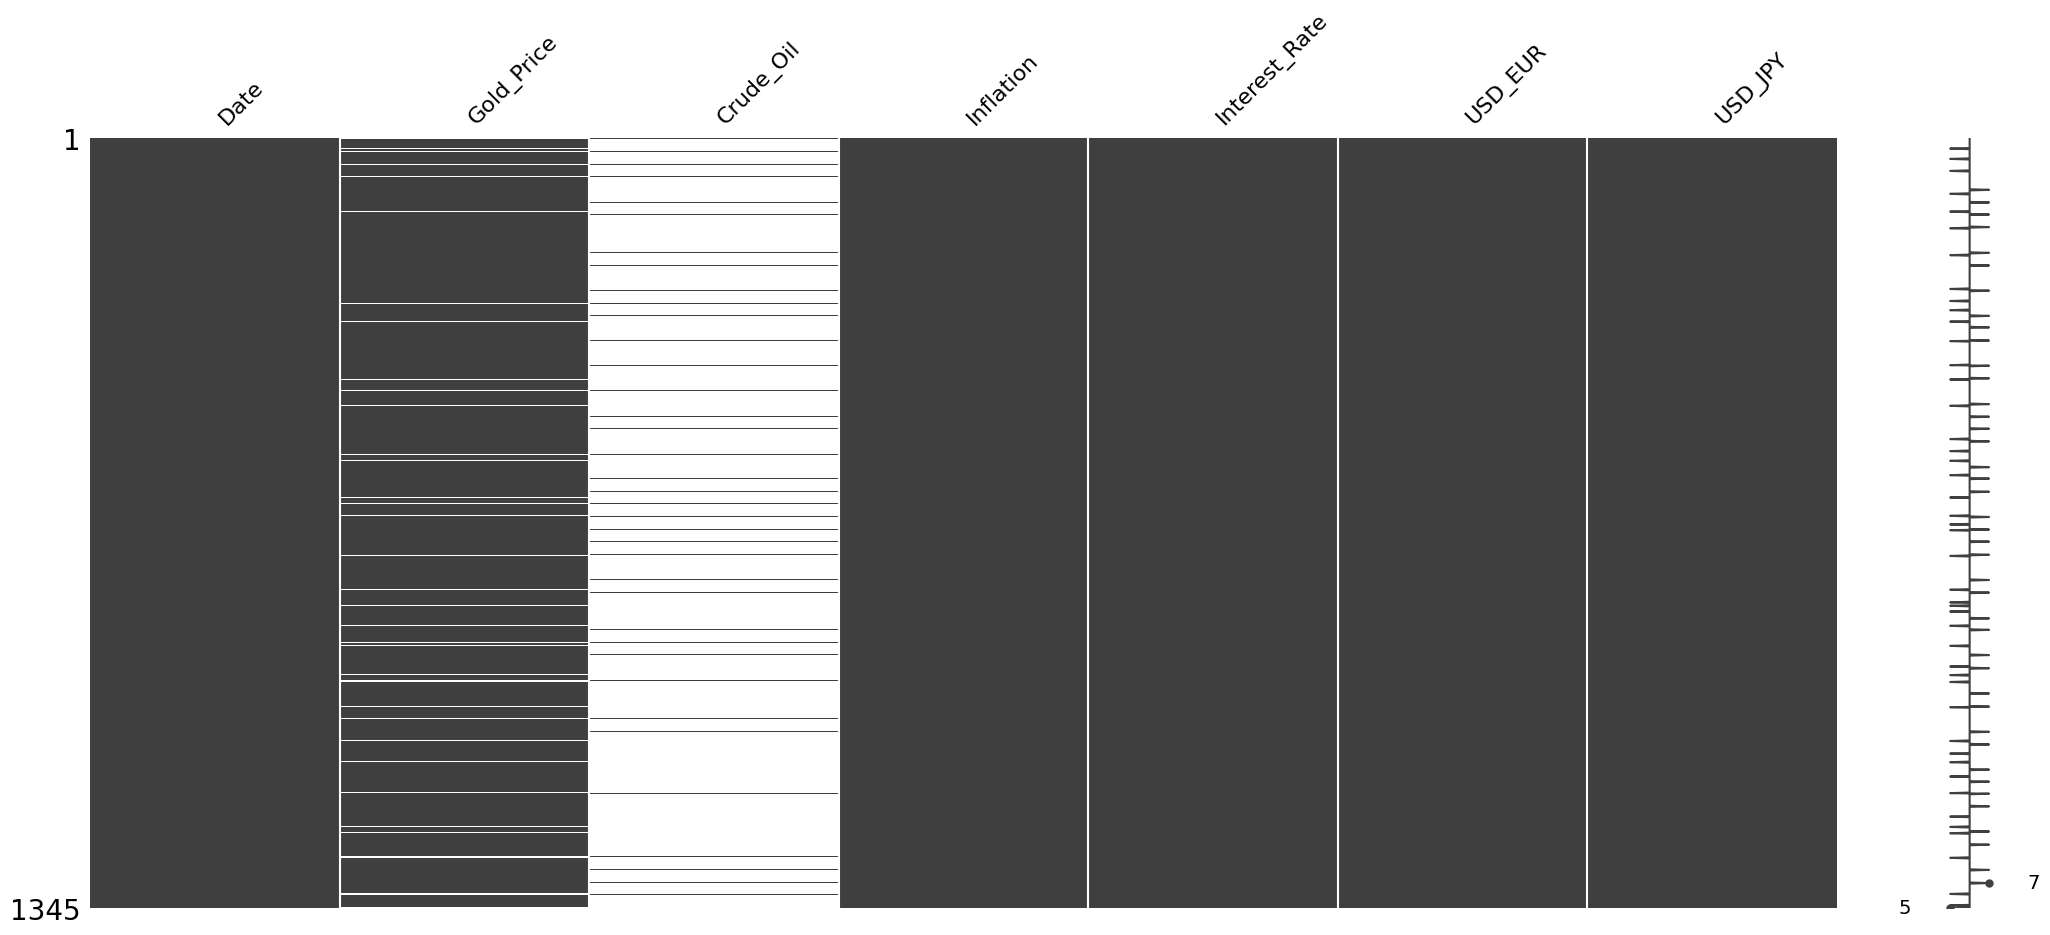

In [17]:
msno.matrix(df)

<Axes: >

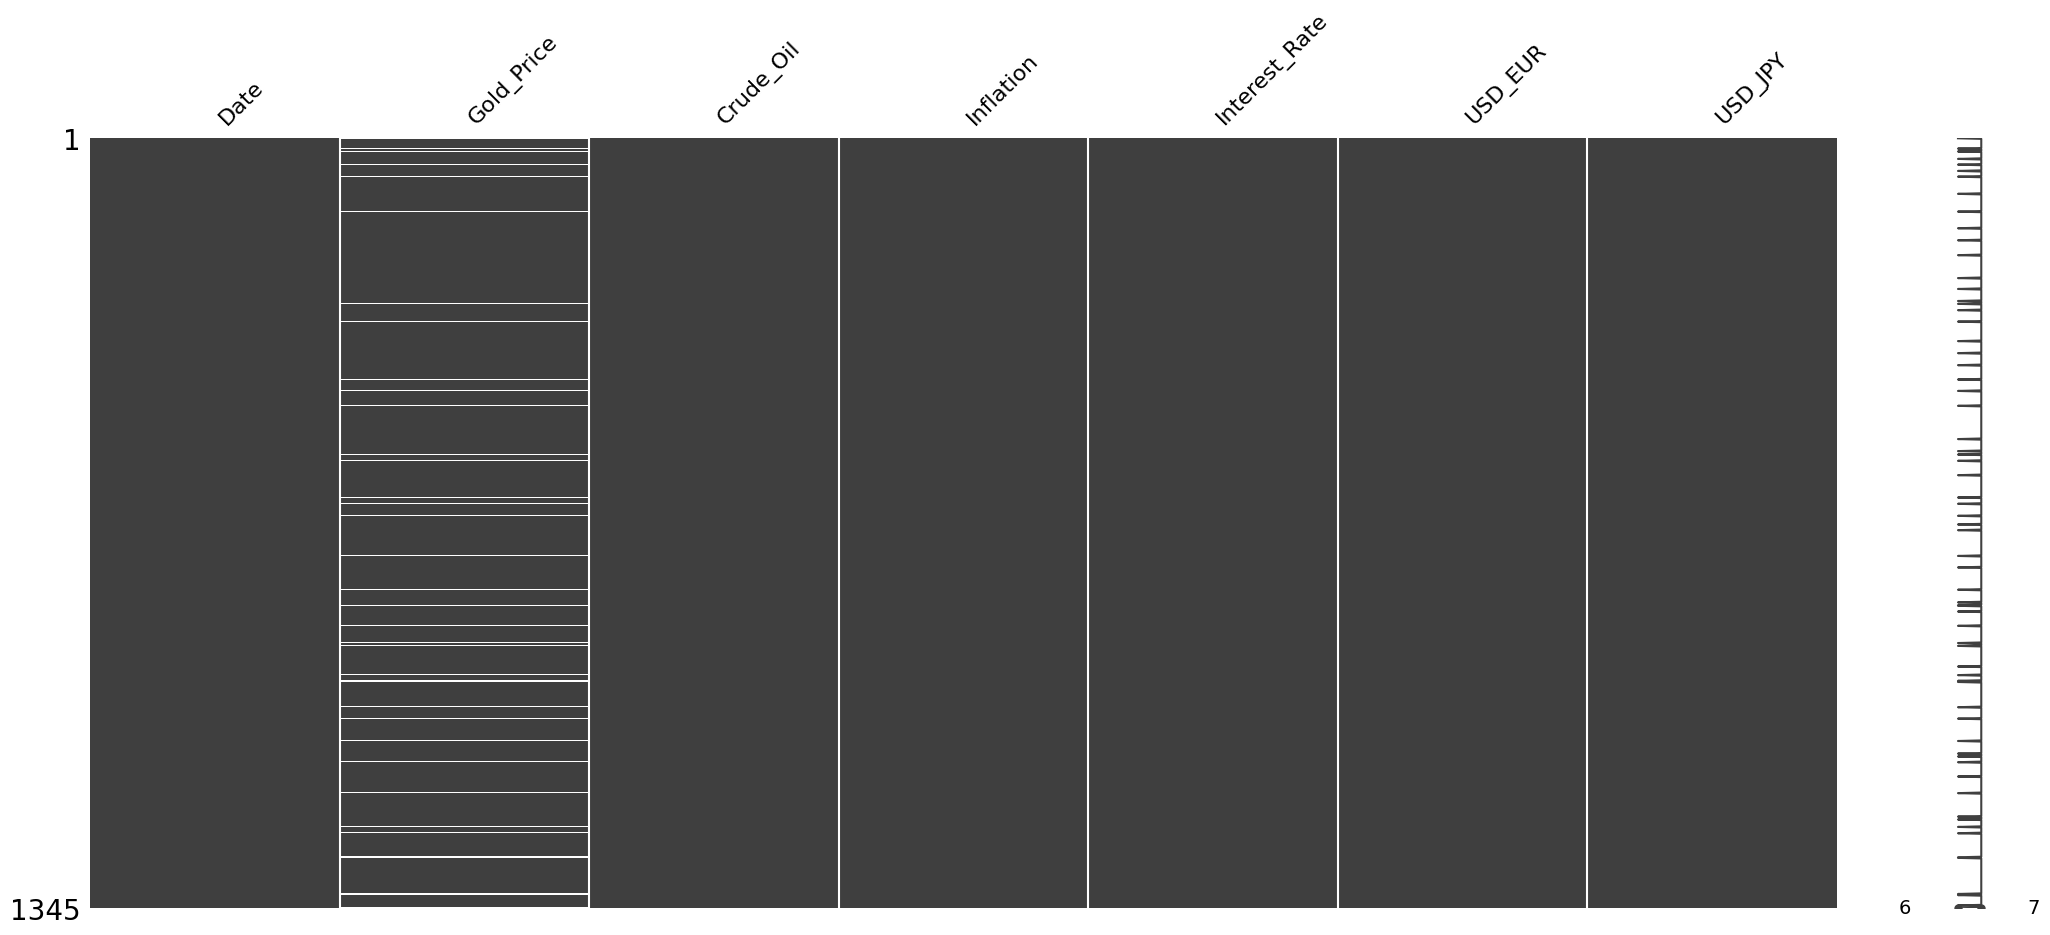

In [18]:
df['Crude_Oil'] = df['Crude_Oil'].ffill()
msno.matrix(df)

Axes(0.125,0.11;0.698618x0.77)
Date             0
Gold_Price       1
Crude_Oil        0
Inflation        0
Interest_Rate    0
USD_EUR          0
USD_JPY          0
dtype: int64


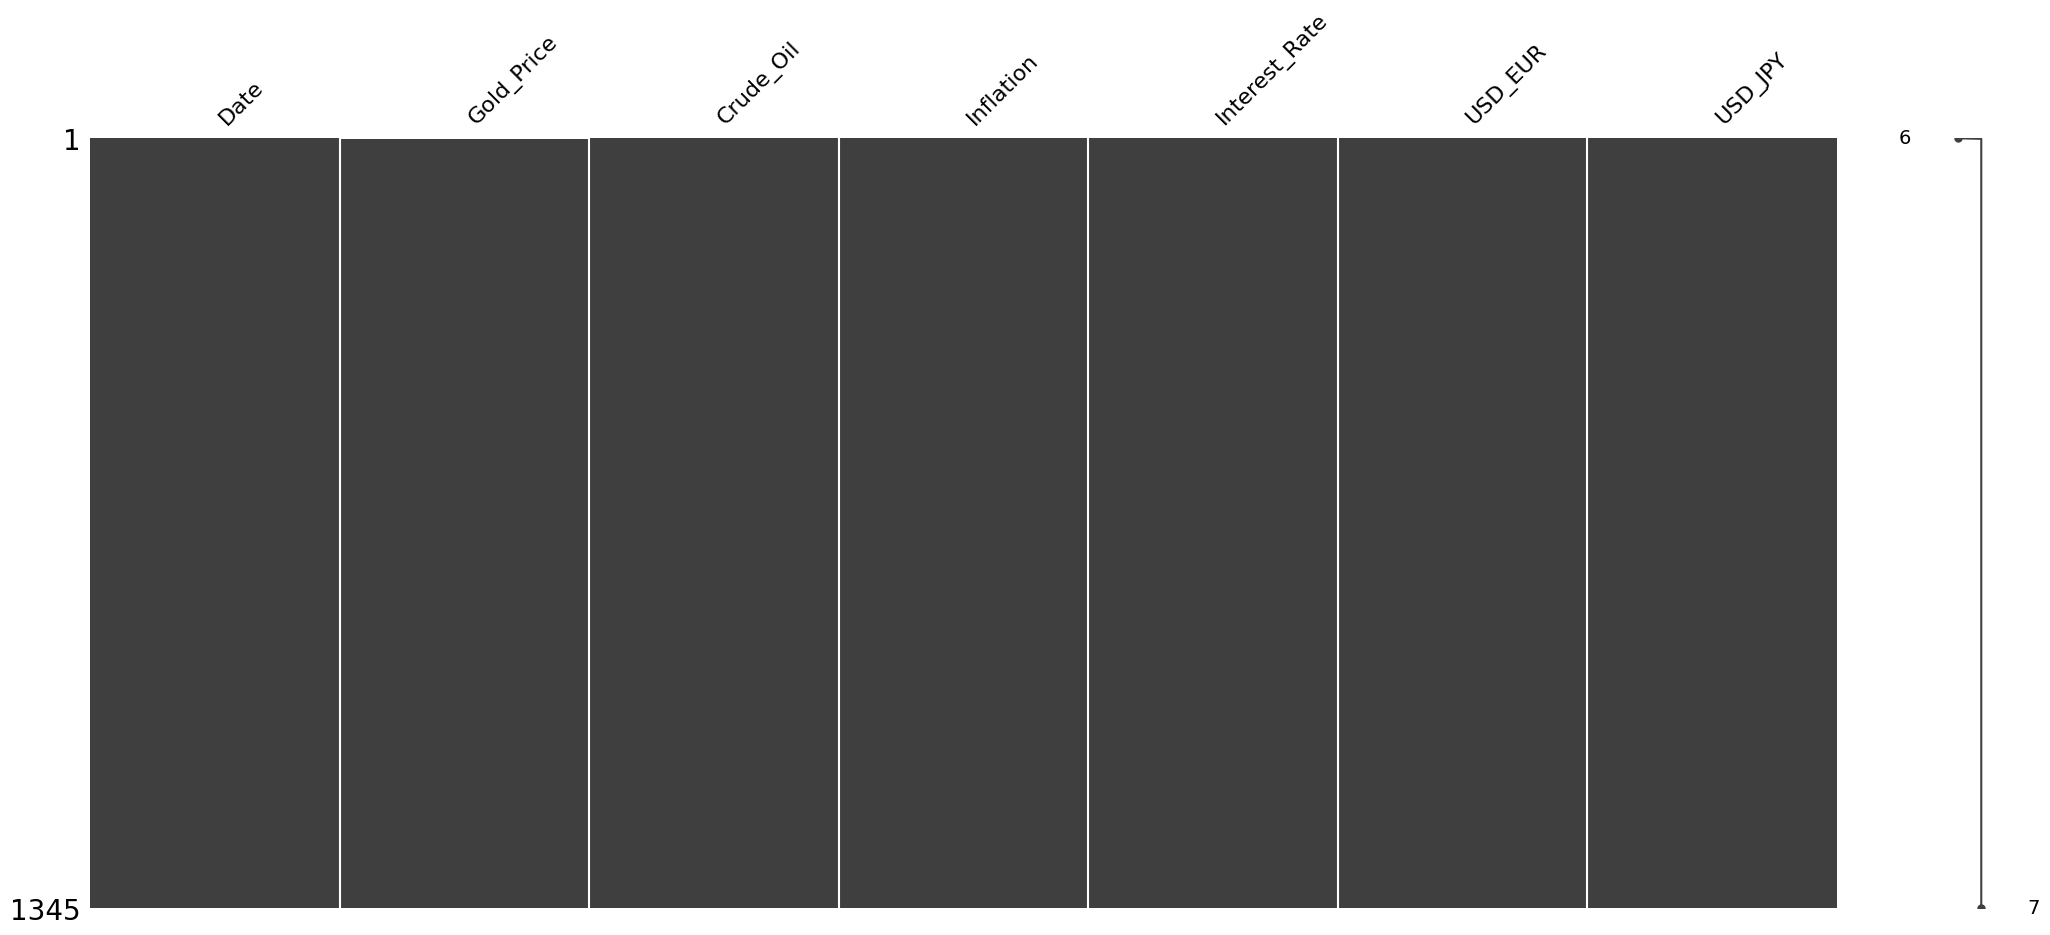

In [19]:
df['Gold_Price'] = df['Gold_Price'].ffill()
print(msno.matrix(df))
print(df.isnull().sum())

In [20]:
df.head()

,Date,Gold_Price,Crude_Oil,Inflation,Interest_Rate,USD_EUR,USD_JPY
0,2019-12-01,NaN,67.31,258.63,1.55,1.1075,109.09
1,2019-12-02,137.789993,67.31,258.63,1.55,1.1075,109.09
2,2019-12-03,139.110001,67.31,258.63,1.55,1.1089,108.53
3,2019-12-04,138.919998,67.31,258.63,1.55,1.1076,108.87
4,2019-12-05,139.000000,67.31,258.63,1.55,1.1104,108.69


In [21]:
df = df.dropna()
df.isnull().sum()

Date             0
Gold_Price       0
Crude_Oil        0
Inflation        0
Interest_Rate    0
USD_EUR          0
USD_JPY          0
dtype: int64

In [22]:
df.to_csv(PATH)

**NEW FEATURES**

In [32]:
import yfinance as yf
import pandas as pd

def fetch_market_data_full(start_date, end_date):
    print("Fetching full market data from Yahoo Finance...")
    
    symbols = {
        'Silver': 'SLV',
        'SP500': '^GSPC'  # Yahoo Finance ticker for S&P 500
    }
    
    dfs = {}
    for name, symbol in symbols.items():
        data = yf.download(symbol, start=start_date, end=end_date)
        data.index = pd.to_datetime(data.index)
        dfs[name] = data  # keep full DataFrame
    
    return dfs  # returns a dictionary of DataFrames

# Example usage
market_data = fetch_market_data_full("2019-12-01", "2025-01-01")

# Access Silver and SP500 separately
silver_df = market_data['Silver']
sp500_df = market_data['SP500']

print("Silver data:")
print(silver_df.head())
print("\nS&P 500 data:")
print(sp500_df.head())


C:\Users\User\AppData\Local\Temp\ipykernel_20476\1711991041.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


C:\Users\User\AppData\Local\Temp\ipykernel_20476\1711991041.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Fetching full market data from Yahoo Finance...
Silver data:
Price           Close   High    Low   Open    Volume
Ticker            SLV    SLV    SLV    SLV       SLV
Date                                                
2019-12-02  15.800000  15.87  15.77  15.80   9176400
2019-12-03  16.049999  16.08  16.00  16.02  13075000
2019-12-04  15.760000  15.95  15.70  15.95  15133700
2019-12-05  15.850000  15.90  15.74  15.74   9086900
2019-12-06  15.480000  15.61  15.44  15.61  19251900

S&P 500 data:
Price             Close         High          Low         Open      Volume
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC       ^GSPC
Date                                                                      
2019-12-02  3113.870117  3144.310059  3110.780029  3143.850098  3285750000
2019-12-03  3093.199951  3094.969971  3070.330078  3087.409912  3671580000
2019-12-04  3112.760010  3119.379883  3102.530029  3103.500000  3702980000
2019-12-05  3117.429932  3119.449951  3103.760010 

In [33]:
silver_df.head()

Price,Close,High,Low,Open,Volume
Ticker,SLV,SLV,SLV,SLV,SLV
Date,,,,,
2019-12-02,15.800000,15.87,15.77,15.80,9176400
2019-12-03,16.049999,16.08,16.00,16.02,13075000
2019-12-04,15.760000,15.95,15.70,15.95,15133700
2019-12-05,15.850000,15.90,15.74,15.74,9086900
2019-12-06,15.480000,15.61,15.44,15.61,19251900


In [34]:
silver_df.columns = ['_'.join(col).strip() for col in silver_df.columns.values]

# Reset index if you want 'Date' as a column
silver_df = silver_df.reset_index()

print(silver_df.head())

        Date  Close_SLV  High_SLV  Low_SLV  Open_SLV  Volume_SLV
0 2019-12-02  15.800000     15.87    15.77     15.80     9176400
1 2019-12-03  16.049999     16.08    16.00     16.02    13075000
2 2019-12-04  15.760000     15.95    15.70     15.95    15133700
3 2019-12-05  15.850000     15.90    15.74     15.74     9086900
4 2019-12-06  15.480000     15.61    15.44     15.61    19251900


In [35]:
silver_df.columns

Index(['Date', 'Close_SLV', 'High_SLV', 'Low_SLV', 'Open_SLV', 'Volume_SLV'], dtype='object')

In [36]:
drop = ['High_SLV', 'Low_SLV', 'Open_SLV', 'Volume_SLV']
silver_df = silver_df.drop(columns=drop)
silver_df.head()

,Date,Close_SLV
0,2019-12-02,15.800000
1,2019-12-03,16.049999
2,2019-12-04,15.760000
3,2019-12-05,15.850000
4,2019-12-06,15.480000


In [37]:
sp500_df.head()

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2019-12-02,3113.870117,3144.310059,3110.780029,3143.850098,3285750000
2019-12-03,3093.199951,3094.969971,3070.330078,3087.409912,3671580000
2019-12-04,3112.760010,3119.379883,3102.530029,3103.500000,3702980000
2019-12-05,3117.429932,3119.449951,3103.760010,3119.209961,3360480000
2019-12-06,3145.909912,3150.600098,3134.620117,3134.620117,3483310000


In [38]:
sp500_df.columns = ['_'.join(col).strip() for col in sp500_df.columns.values]

sp500_df = sp500_df.reset_index()

print(sp500_df.head())

        Date  Close_^GSPC   High_^GSPC    Low_^GSPC   Open_^GSPC  Volume_^GSPC
0 2019-12-02  3113.870117  3144.310059  3110.780029  3143.850098    3285750000
1 2019-12-03  3093.199951  3094.969971  3070.330078  3087.409912    3671580000
2 2019-12-04  3112.760010  3119.379883  3102.530029  3103.500000    3702980000
3 2019-12-05  3117.429932  3119.449951  3103.760010  3119.209961    3360480000
4 2019-12-06  3145.909912  3150.600098  3134.620117  3134.620117    3483310000


In [40]:
sp500_df.columns

Index(['Date', 'Close_^GSPC', 'High_^GSPC', 'Low_^GSPC', 'Open_^GSPC',
       'Volume_^GSPC'],
      dtype='object')

In [41]:
drop = ['High_^GSPC', 'Low_^GSPC', 'Open_^GSPC', 'Volume_^GSPC']

sp500_df = sp500_df.drop(columns=drop)
sp500_df.head()

,Date,Close_^GSPC
0,2019-12-02,3113.870117
1,2019-12-03,3093.199951
2,2019-12-04,3112.760010
3,2019-12-05,3117.429932
4,2019-12-06,3145.909912


In [42]:
sp500_df = sp500_df.rename(columns={'Close_^GSPC': '^GSPC'})
sp500_df.head()

,Date,^GSPC
0,2019-12-02,3113.870117
1,2019-12-03,3093.199951
2,2019-12-04,3112.760010
3,2019-12-05,3117.429932
4,2019-12-06,3145.909912


In [43]:
len(sp500_df)

1279

In [46]:
silver_df = silver_df.rename(columns={'Close_SLV': 'SLV'})
print(silver_df.head())
print(len(silver_df))

        Date        SLV
0 2019-12-02  15.800000
1 2019-12-03  16.049999
2 2019-12-04  15.760000
3 2019-12-05  15.850000
4 2019-12-06  15.480000
1279


In [47]:
merged = pd.merge(silver_df, sp500_df, on='Date', how='inner')
print(merged.head())
print(merged.tail())
print(len(merged))

        Date        SLV        ^GSPC
0 2019-12-02  15.800000  3113.870117
1 2019-12-03  16.049999  3093.199951
2 2019-12-04  15.760000  3112.760010
3 2019-12-05  15.850000  3117.429932
4 2019-12-06  15.480000  3145.909912
           Date        SLV        ^GSPC
1274 2024-12-24  27.020000  6040.040039
1275 2024-12-26  27.139999  6037.589844
1276 2024-12-27  26.760000  5970.839844
1277 2024-12-30  26.430000  5906.939941
1278 2024-12-31  26.330000  5881.629883
1279


In [50]:
path = 'datasets/gold_data.csv'
df = pd.read_csv(path, parse_dates=['Date'])
print(df.head())
print(len(df))

   Unnamed: 0       Date  Gold_Price  Crude_Oil  Inflation  Interest_Rate  \
0           1 2019-12-02  137.789993      67.31     258.63           1.55   
1           2 2019-12-03  139.110001      67.31     258.63           1.55   
2           3 2019-12-04  138.919998      67.31     258.63           1.55   
3           4 2019-12-05  139.000000      67.31     258.63           1.55   
4           5 2019-12-06  137.619995      67.31     258.63           1.55   

   USD_EUR  USD_JPY  
0   1.1075   109.09  
1   1.1089   108.53  
2   1.1076   108.87  
3   1.1104   108.69  
4   1.1052   108.66  
1344


In [51]:
df = df.drop(columns=['Unnamed: 0'])
df.head()

,Date,Gold_Price,Crude_Oil,Inflation,Interest_Rate,USD_EUR,USD_JPY
0,2019-12-02,137.789993,67.31,258.63,1.55,1.1075,109.09
1,2019-12-03,139.110001,67.31,258.63,1.55,1.1089,108.53
2,2019-12-04,138.919998,67.31,258.63,1.55,1.1076,108.87
3,2019-12-05,139.000000,67.31,258.63,1.55,1.1104,108.69
4,2019-12-06,137.619995,67.31,258.63,1.55,1.1052,108.66


In [52]:
merged2 = pd.merge(df, merged, on='Date', how='inner')
merged2.head()

,Date,Gold_Price,Crude_Oil,Inflation,Interest_Rate,USD_EUR,USD_JPY,SLV,^GSPC
0,2019-12-02,137.789993,67.31,258.63,1.55,1.1075,109.09,15.800000,3113.870117
1,2019-12-03,139.110001,67.31,258.63,1.55,1.1089,108.53,16.049999,3093.199951
2,2019-12-04,138.919998,67.31,258.63,1.55,1.1076,108.87,15.760000,3112.760010
3,2019-12-05,139.000000,67.31,258.63,1.55,1.1104,108.69,15.850000,3117.429932
4,2019-12-06,137.619995,67.31,258.63,1.55,1.1052,108.66,15.480000,3145.909912


<Axes: >

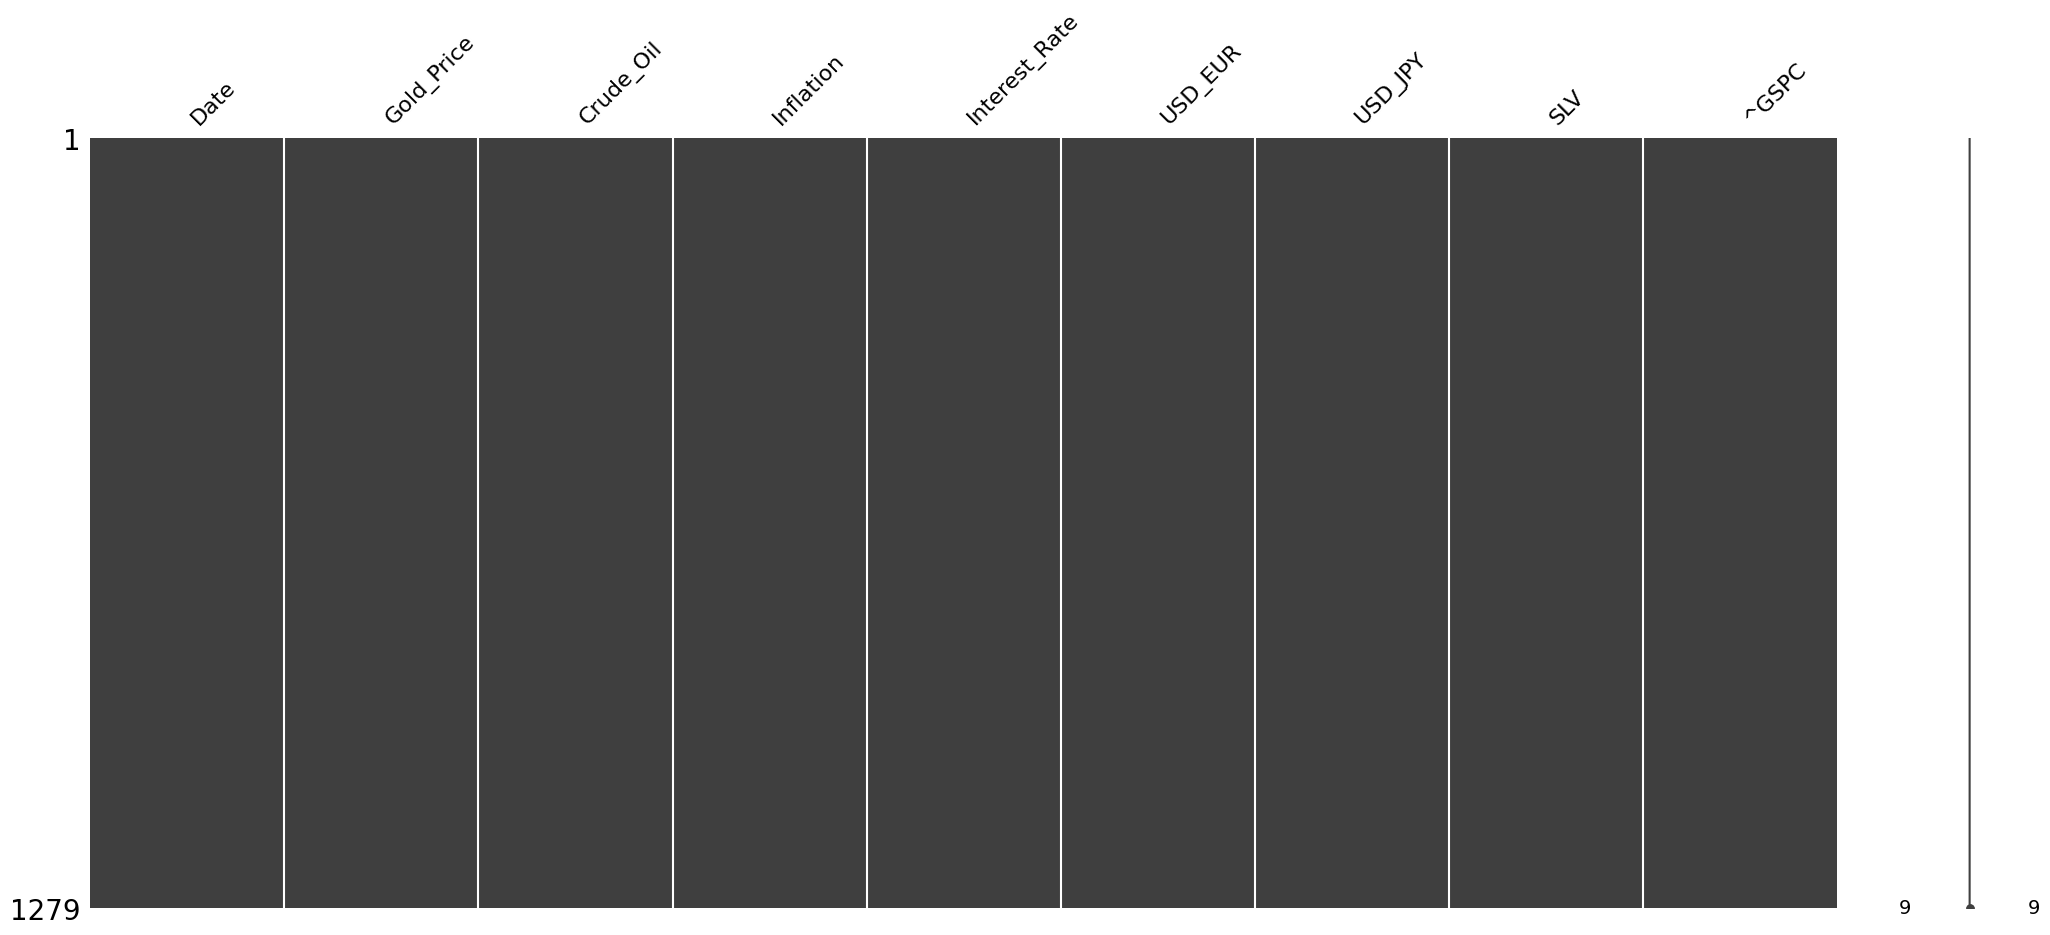

In [53]:
msno.matrix(merged2)

In [54]:
merged2.isnull().sum()

Date             0
Gold_Price       0
Crude_Oil        0
Inflation        0
Interest_Rate    0
USD_EUR          0
USD_JPY          0
SLV              0
^GSPC            0
dtype: int64

In [55]:
path = 'datasets/gold_data.csv'
merged2.to_csv(path, index=False)